# Final Infrared Temperature Prediction Model

This notebook builds, evaluates, and saves the final production-ready machine learning pipeline for predicting oral temperature from infrared thermography and related demographic/environmental features.

**Target:** `aveOralF`

**Final Model:** Gradient Boosting Regressor

In [2]:
# Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load dataset
df_clean = pd.read_csv("../data/cleaned.csv")

print(df_clean.shape)
df_clean.head()

(1020, 34)


,Gender,Age,Ethnicity,T_atm,Humidity,Distance,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,...,T_FHRC1,T_FHLC1,T_FHBC1,T_FHTC1,T_FH_Max1,T_FHC_Max1,T_Max1,T_OR1,T_OR_Max1,aveOralF
0,Male,41-50,White,24.0,28.0,0.8,0.7025,35.0300,35.3775,34.4000,...,33.4775,33.3725,33.4925,33.0025,34.5300,34.0075,35.6925,35.6350,35.6525,36.85
1,Female,31-40,Black or African-American,24.0,26.0,0.8,0.7800,34.5500,34.5200,33.9300,...,34.0550,33.6775,33.9700,34.0025,34.6825,34.6600,35.1750,35.0925,35.1075,37.00
2,Female,21-30,White,24.0,26.0,0.8,0.8625,35.6525,35.5175,34.2775,...,34.8275,34.6475,34.8200,34.6700,35.3450,35.2225,35.9125,35.8600,35.8850,37.20
3,Female,21-30,Black or African-American,24.0,27.0,0.8,0.9300,35.2225,35.6125,34.3850,...,34.4225,34.6550,34.3025,34.9175,35.6025,35.3150,35.7200,34.9650,34.9825,36.85
4,Male,18-20,White,24.0,27.0,0.8,0.8950,35.5450,35.6650,34.9100,...,35.1600,34.3975,34.6700,33.8275,35.4175,35.3725,35.8950,35.5875,35.6175,36.80


## Feature and Target Definition

The objective is to predict `aveOralF`, which represents the average oral temperature measured in fast mode.

`aveOralM` is excluded from the predictor variables because it is another oral temperature measurement and could introduce target leakage.

In [4]:
# Define X and y
X = df_clean.drop(columns=["aveOralF"])
y = df_clean["aveOralF"]

## Feature Type Identification

The dataset contains three categorical variables and thirty numerical variables.

Categorical variables require encoding before they can be used by the machine learning model.

In [5]:
# Define feature types
categorical_features = [
    "Gender",
    "Age",
    "Ethnicity"
]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Categorical features:", categorical_features)
print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features: ['Gender', 'Age', 'Ethnicity']
Number of categorical features: 3
Number of numerical features: 30


In [6]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (816, 33)
Testing features: (204, 33)
Training target: (816,)
Testing target: (204,)


## Preprocessing Pipeline

The preprocessing stage handles numerical and categorical features separately.

- Numerical features: missing values are replaced using the median.
- Categorical features: missing values are replaced using the most frequent category.
- Categorical variables are converted into numerical representations using one-hot encoding.

The preprocessing steps are incorporated into a single pipeline to prevent data leakage and ensure consistent transformations during model deployment.

In [7]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [8]:
# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [9]:
# Combine both preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Final Model

Gradient Boosting Regressor was selected as the final model based on its superior performance during baseline model comparison.

The model achieved the best test-set performance among the evaluated algorithms.

In [10]:
# Create final model
final_model = GradientBoostingRegressor(
    random_state=42
)


In [11]:
# Combine preprocessing + model
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_model)
    ]
)

In [12]:
# Train the pipeline
final_pipeline.fit(X_train, y_train)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [13]:
# Generate predictions
final_predictions = final_pipeline.predict(X_test)

In [14]:
print(final_predictions[:10])

[36.99380315 36.73660589 36.64142905 36.8820406  36.8680904  36.96396464
 37.41171074 36.95992331 36.92241    36.87919948]


In [15]:
# Evaluate the final pipeline
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print(f"Final MAE:  {final_mae:.4f} °C")
print(f"Final RMSE: {final_rmse:.4f} °C")
print(f"Final R²:   {final_r2:.4f}")

Final MAE:  0.1659 °C
Final RMSE: 0.2179 °C
Final R²:   0.6056


In [16]:
# Create your final metrics table
final_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "Value": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

final_results.round(4)

,Metric,Value
0,MAE,0.1659
1,RMSE,0.2179
2,R²,0.6056


## Final Model Cross-Validation

Five-fold cross-validation is used to evaluate the stability and generalization of the final production pipeline across multiple training and validation splits.

In [17]:
cv_results = cross_validate(
    final_pipeline,
    X,
    y,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    n_jobs=-1
)

In [18]:
# Calculate the CV results
cv_r2 = cv_results["test_r2"]

cv_mae = -cv_results["test_mae"]

cv_rmse = -cv_results["test_rmse"]

print(f"Mean R²:   {cv_r2.mean():.4f}")
print(f"Std R²:    {cv_r2.std():.4f}")

print(f"Mean MAE:  {cv_mae.mean():.4f} °C")
print(f"Std MAE:   {cv_mae.std():.4f} °C")

print(f"Mean RMSE: {cv_rmse.mean():.4f} °C")
print(f"Std RMSE:  {cv_rmse.std():.4f} °C")

Mean R²:   0.5106
Std R²:    0.1858
Mean MAE:  0.1766 °C
Std MAE:   0.0184 °C
Mean RMSE: 0.2480 °C
Std RMSE:  0.0306 °C


In [19]:
# Create the final validation summary
final_validation_summary = pd.DataFrame({
    "Evaluation": [
        "Test Set",
        "5-Fold Cross-Validation"
    ],
    "MAE": [
        final_mae,
        cv_mae.mean()
    ],
    "RMSE": [
        final_rmse,
        cv_rmse.mean()
    ],
    "R²": [
        final_r2,
        cv_r2.mean()
    ]
})

final_validation_summary.round(4)

,Evaluation,MAE,RMSE,R²
0,Test Set,0.1659,0.2179,0.6056
1,5-Fold Cross-Validation,0.1766,0.2480,0.5106


In [20]:
import os

os.makedirs("../models", exist_ok=True)

In [21]:
# Save model
joblib.dump(
    final_pipeline,
    "../models/infrared_temperature_pipeline.pkl"
)

print("Final production pipeline saved successfully.")

Final production pipeline saved successfully.


In [22]:
# Test that the saved model actually works
loaded_pipeline = joblib.load(
    "../models/infrared_temperature_pipeline.pkl"
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [23]:
loaded_predictions = loaded_pipeline.predict(X_test)

print("Predictions generated successfully.")
print(loaded_predictions[:5])

Predictions generated successfully.
[36.99380315 36.73660589 36.64142905 36.8820406  36.8680904 ]


In [24]:
# Then compare the loaded predictions with our original predictions
np.allclose(
    final_predictions,
    loaded_predictions
)

True

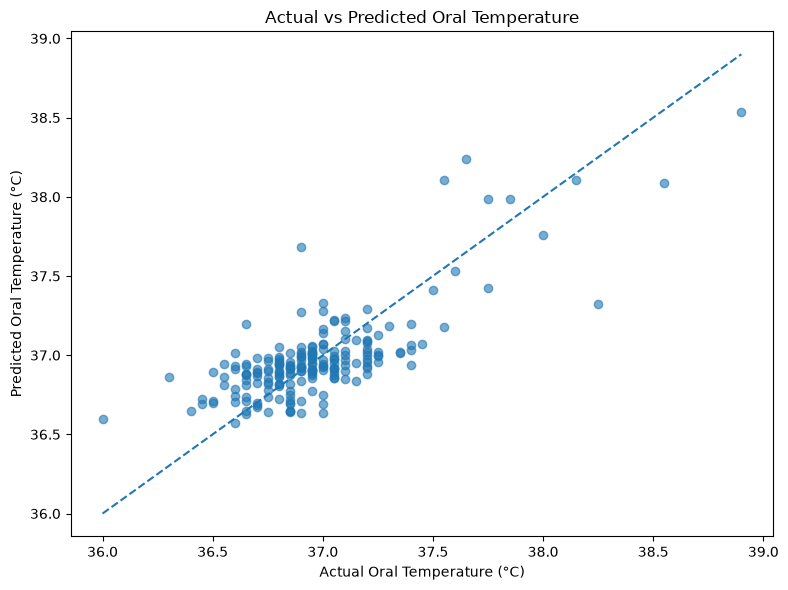

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Oral Temperature (°C)")
plt.ylabel("Predicted Oral Temperature (°C)")
plt.title("Actual vs Predicted Oral Temperature")

plt.tight_layout()
plt.show()

In [26]:
residuals = y_test - final_predictions

print(residuals.describe())

count    204.000000
mean      -0.011958
std        0.218069
min       -0.782188
25%       -0.143984
50%       -0.021083
75%        0.122730
max        0.928764
Name: aveOralF, dtype: float64


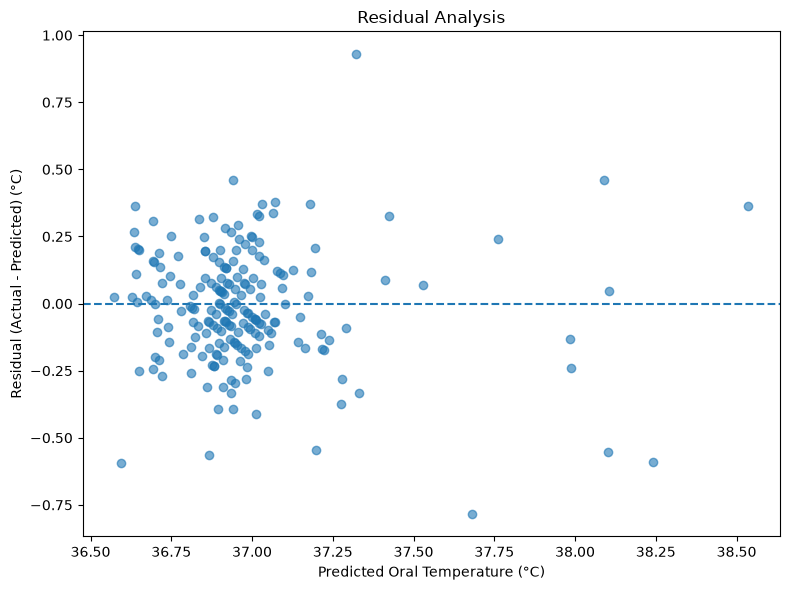

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Oral Temperature (°C)")
plt.ylabel("Residual (Actual - Predicted) (°C)")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

## Model Explainability

Feature importance is extracted from the trained Gradient Boosting model to identify which infrared, environmental, and demographic variables contribute most strongly to the model's predictions.

In [35]:
# Get the fitted preprocessor
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(feature_names)

Number of transformed features: 46
['num__T_atm' 'num__Humidity' 'num__Distance' 'num__T_offset1'
 'num__Max1R13_1' 'num__Max1L13_1' 'num__aveAllR13_1' 'num__aveAllL13_1'
 'num__T_RC1' 'num__T_RC_Dry1' 'num__T_RC_Wet1' 'num__T_RC_Max1'
 'num__T_LC1' 'num__T_LC_Dry1' 'num__T_LC_Wet1' 'num__T_LC_Max1'
 'num__RCC1' 'num__LCC1' 'num__canthiMax1' 'num__canthi4Max1'
 'num__T_FHCC1' 'num__T_FHRC1' 'num__T_FHLC1' 'num__T_FHBC1'
 'num__T_FHTC1' 'num__T_FH_Max1' 'num__T_FHC_Max1' 'num__T_Max1'
 'num__T_OR1' 'num__T_OR_Max1' 'cat__Gender_Female' 'cat__Gender_Male'
 'cat__Age_18-20' 'cat__Age_21-25' 'cat__Age_21-30' 'cat__Age_26-30'
 'cat__Age_31-40' 'cat__Age_41-50' 'cat__Age_51-60' 'cat__Age_>60'
 'cat__Ethnicity_American Indian or Alaskan Native' 'cat__Ethnicity_Asian'
 'cat__Ethnicity_Black or African-American'
 'cat__Ethnicity_Hispanic/Latino' 'cat__Ethnicity_Multiracial'
 'cat__Ethnicity_White']


In [36]:
# Extract feature importance
final_gb_model = final_pipeline.named_steps["model"]

In [37]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_gb_model.feature_importances_
})

In [38]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [39]:
feature_importance.head(15)

,Feature,Importance
29,num__T_OR_Max1,0.347453
27,num__T_Max1,0.280426
28,num__T_OR1,0.127245
25,num__T_FH_Max1,0.030814
10,num__T_RC_Wet1,0.023139
9,num__T_RC_Dry1,0.022981
21,num__T_FHRC1,0.015879
3,num__T_offset1,0.014802
0,num__T_atm,0.011968
16,num__RCC1,0.011333


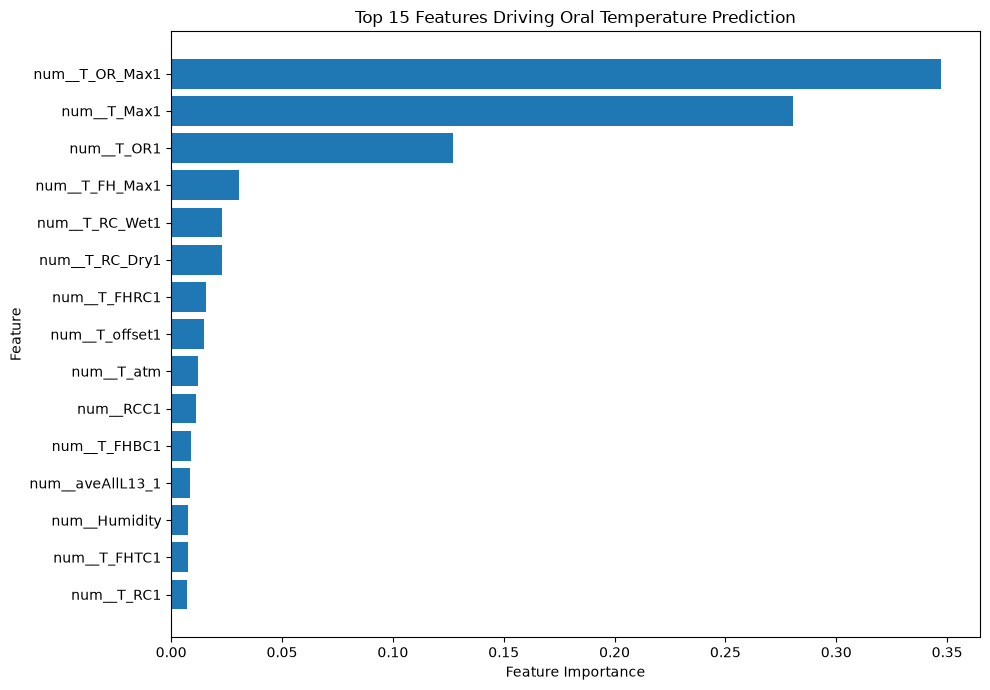

In [42]:
# Visualize the top features
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Driving Oral Temperature Prediction")

plt.tight_layout()
plt.show()

In [43]:
# Save the feature importance table
feature_importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


## Target Leakage Check

Before deployment, potential target leakage is investigated to ensure that the predictor variables contain information that would realistically be available when making a prediction.

In [44]:
# Check correlations with the target
correlations = df_clean.select_dtypes(
    include="number"
).corr()["aveOralF"].sort_values(
    ascending=False
)

correlations

aveOralF       1.000000
T_Max1         0.752546
T_OR1          0.718840
T_OR_Max1      0.718513
canthiMax1     0.673136
canthi4Max1    0.672514
T_RC_Max1      0.664864
T_RC1          0.664154
T_RC_Wet1      0.654099
T_RC_Dry1      0.643588
Max1R13_1      0.637134
T_LC_Max1      0.633186
T_LC1          0.633009
T_LC_Dry1      0.627341
Max1L13_1      0.621410
RCC1           0.611695
T_LC_Wet1      0.611027
LCC1           0.586546
T_FH_Max1      0.560117
aveAllL13_1    0.540581
aveAllR13_1    0.534192
T_FHC_Max1     0.502194
T_FHBC1        0.472456
T_FHCC1        0.433403
T_FHRC1        0.425942
T_FHLC1        0.399649
T_FHTC1        0.382936
T_offset1      0.117794
T_atm          0.070825
Humidity       0.047200
Distance       0.016112
Name: aveOralF, dtype: float64

In [45]:
# Check the target-related variables
correlations.drop("aveOralF").head(10)

T_Max1         0.752546
T_OR1          0.718840
T_OR_Max1      0.718513
canthiMax1     0.673136
canthi4Max1    0.672514
T_RC_Max1      0.664864
T_RC1          0.664154
T_RC_Wet1      0.654099
T_RC_Dry1      0.643588
Max1R13_1      0.637134
Name: aveOralF, dtype: float64

In [46]:
correlations.drop("aveOralF").tail(10)

T_FHC_Max1    0.502194
T_FHBC1       0.472456
T_FHCC1       0.433403
T_FHRC1       0.425942
T_FHLC1       0.399649
T_FHTC1       0.382936
T_offset1     0.117794
T_atm         0.070825
Humidity      0.047200
Distance      0.016112
Name: aveOralF, dtype: float64

In [48]:
# Check for duplicate predictors
duplicate_columns = []

columns = df_clean.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if df_clean[columns[i]].equals(df_clean[columns[j]]):
            duplicate_columns.append(
                (columns[i], columns[j])
            )

duplicate_columns

[]

In [49]:
# Check highly correlated predictors
feature_corr = X.select_dtypes(
    include="number"
).corr().abs()

upper_triangle = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

high_correlations = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_correlations.head(15)

T_RC1       T_RC_Max1      0.999788
canthiMax1  canthi4Max1    0.999786
T_LC1       T_LC_Max1      0.999764
T_OR1       T_OR_Max1      0.999756
Max1R13_1   T_RC_Dry1      0.995478
T_LC1       T_LC_Dry1      0.994779
T_LC_Dry1   T_LC_Max1      0.994190
Max1L13_1   T_LC_Dry1      0.993080
            T_LC1          0.988479
            T_LC_Max1      0.988293
T_RC1       T_RC_Dry1      0.982699
Max1R13_1   T_RC1          0.981819
T_RC_Dry1   T_RC_Max1      0.981766
Max1R13_1   T_RC_Max1      0.981113
T_RC1       T_RC_Wet1      0.974507
dtype: float64

## Leakage Assessment

The target variable `aveOralF` was excluded from the predictor set, and `aveOralM` was also excluded because it represents another direct oral temperature measurement that would not be appropriate as an input for a non-invasive prediction scenario.

The remaining predictors consist of demographic, environmental, and infrared thermography measurements that can realistically serve as model inputs.

Although several infrared features are strongly correlated with one another, this is expected because they represent different measurements extracted from overlapping facial regions. Gradient Boosting can handle correlated predictors without requiring strict feature elimination.

In [50]:
print("aveOralM present:", "aveOralM" in df_clean.columns)

aveOralM present: False
